# Exploratory Data Analysis - Phishing Email Dataset
## LSTM-Driven Phishing Detection for Enterprise Email Security

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Dataset

In [5]:
df = pd.read_csv('../Dataset/phishing_email.csv')
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
df.head()

Dataset Shape: (82486, 2)

Columns: ['text_combined', 'label']

Data Types:
text_combined    object
label             int64
dtype: object

Missing Values:
text_combined    0
label            0
dtype: int64


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


## 2. Label Distribution

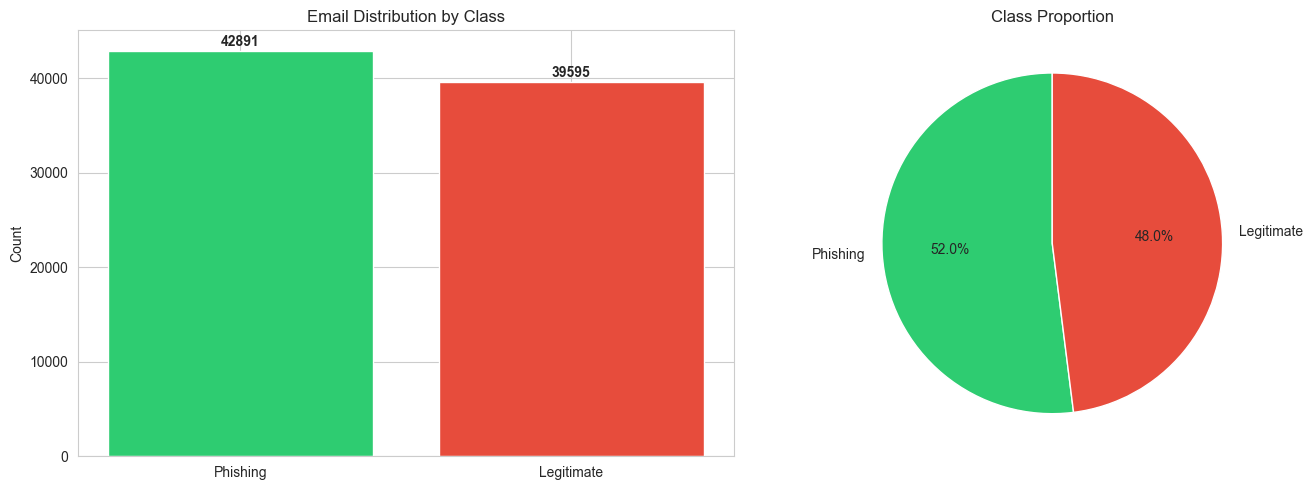


Class Balance Ratio: 0.923


In [6]:
label_counts = df['label'].value_counts()
label_names = {0: 'Legitimate', 1: 'Phishing'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar([label_names[i] for i in label_counts.index], label_counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Email Distribution by Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=[label_names[i] for i in label_counts.index],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('../results/label_distribution.png', dpi=150)
plt.show()

print(f"\nClass Balance Ratio: {label_counts.min()/label_counts.max():.3f}")

## 3. Text Length Analysis

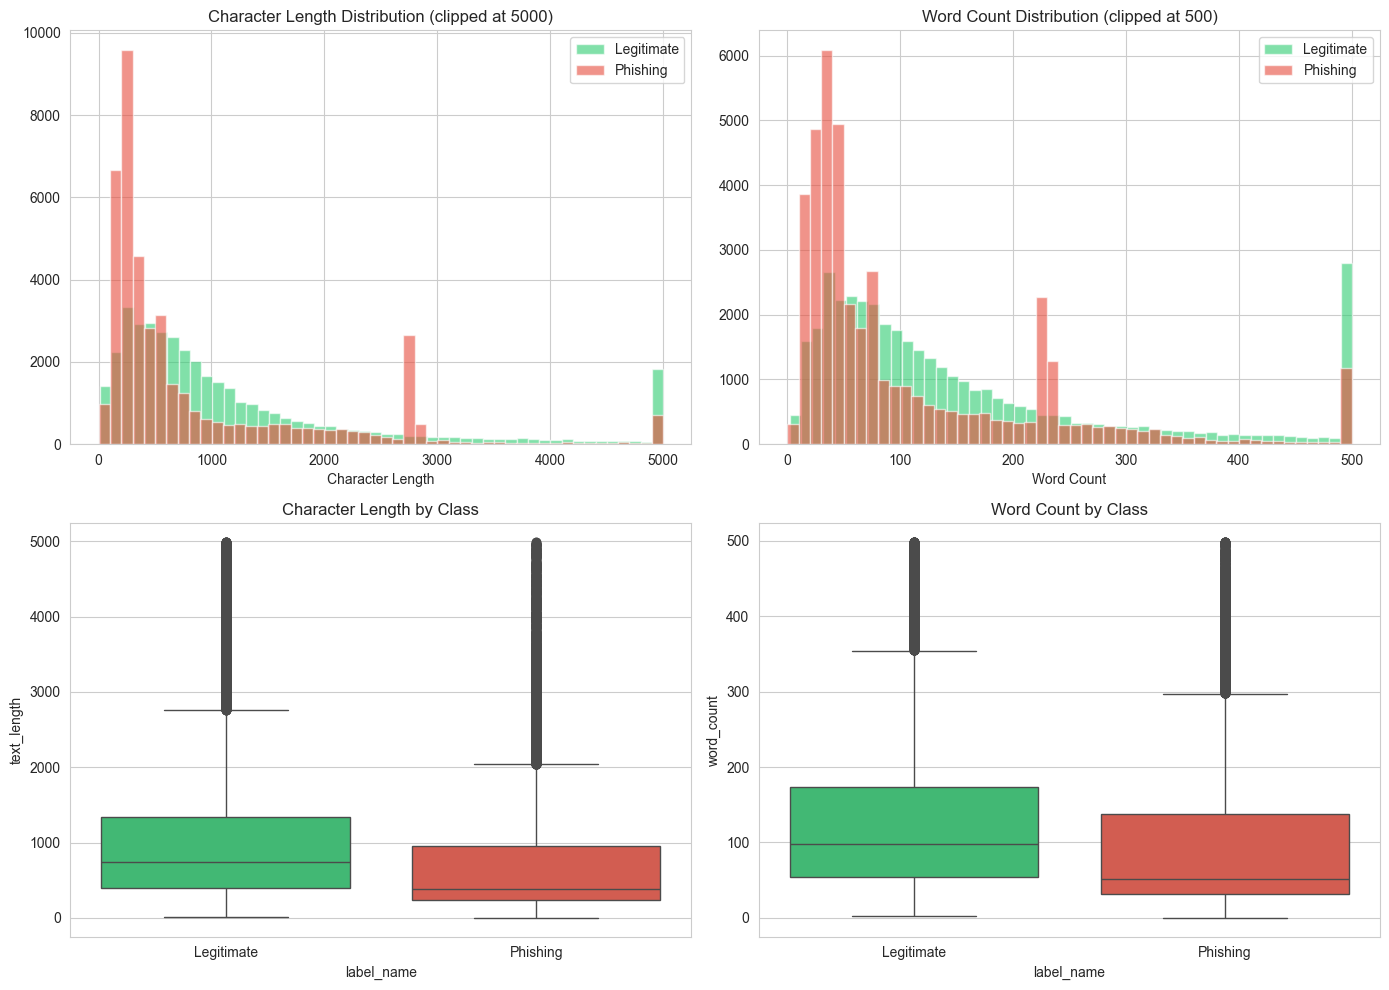


Length Statistics:
      text_length                                                         \
            count         mean           std   min    25%    50%     75%   
label                                                                      
0         39595.0  1536.096098   3695.897909  11.0  411.0  779.0  1493.0   
1         42891.0  1060.413793  21192.696303   1.0  241.0  391.0  1058.0   

                 word_count                                                   \
             max      count        mean         std  min   25%    50%    75%   
label                                                                          
0       160318.0    39595.0  203.182068  479.176830  2.0  57.0  106.0  203.0   
1      4279526.0    42891.0  121.342543  594.451146  0.0  32.0   55.0  154.0   

                 
            max  
label            
0       23359.0  
1      107710.0  


In [7]:
df['text_length'] = df['text_combined'].astype(str).apply(len)
df['word_count'] = df['text_combined'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Text length distribution
for label, color, name in [(0, '#2ecc71', 'Legitimate'), (1, '#e74c3c', 'Phishing')]:
    subset = df[df['label'] == label]
    axes[0, 0].hist(subset['text_length'].clip(upper=5000), bins=50,
                    alpha=0.6, color=color, label=name)
axes[0, 0].set_title('Character Length Distribution (clipped at 5000)')
axes[0, 0].set_xlabel('Character Length')
axes[0, 0].legend()

# Word count distribution
for label, color, name in [(0, '#2ecc71', 'Legitimate'), (1, '#e74c3c', 'Phishing')]:
    subset = df[df['label'] == label]
    axes[0, 1].hist(subset['word_count'].clip(upper=500), bins=50,
                    alpha=0.6, color=color, label=name)
axes[0, 1].set_title('Word Count Distribution (clipped at 500)')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].legend()

# Box plots
df_plot = df[df['text_length'] < 5000].copy()
df_plot['label_name'] = df_plot['label'].map(label_names)
sns.boxplot(data=df_plot, x='label_name', y='text_length', ax=axes[1, 0],
            palette=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Character Length by Class')

df_plot2 = df[df['word_count'] < 500].copy()
df_plot2['label_name'] = df_plot2['label'].map(label_names)
sns.boxplot(data=df_plot2, x='label_name', y='word_count', ax=axes[1, 1],
            palette=['#2ecc71', '#e74c3c'])
axes[1, 1].set_title('Word Count by Class')

plt.tight_layout()
plt.savefig('../results/text_length_analysis.png', dpi=150)
plt.show()

print("\nLength Statistics:")
print(df.groupby('label')[['text_length', 'word_count']].describe())

## 4. Most Common Words Analysis

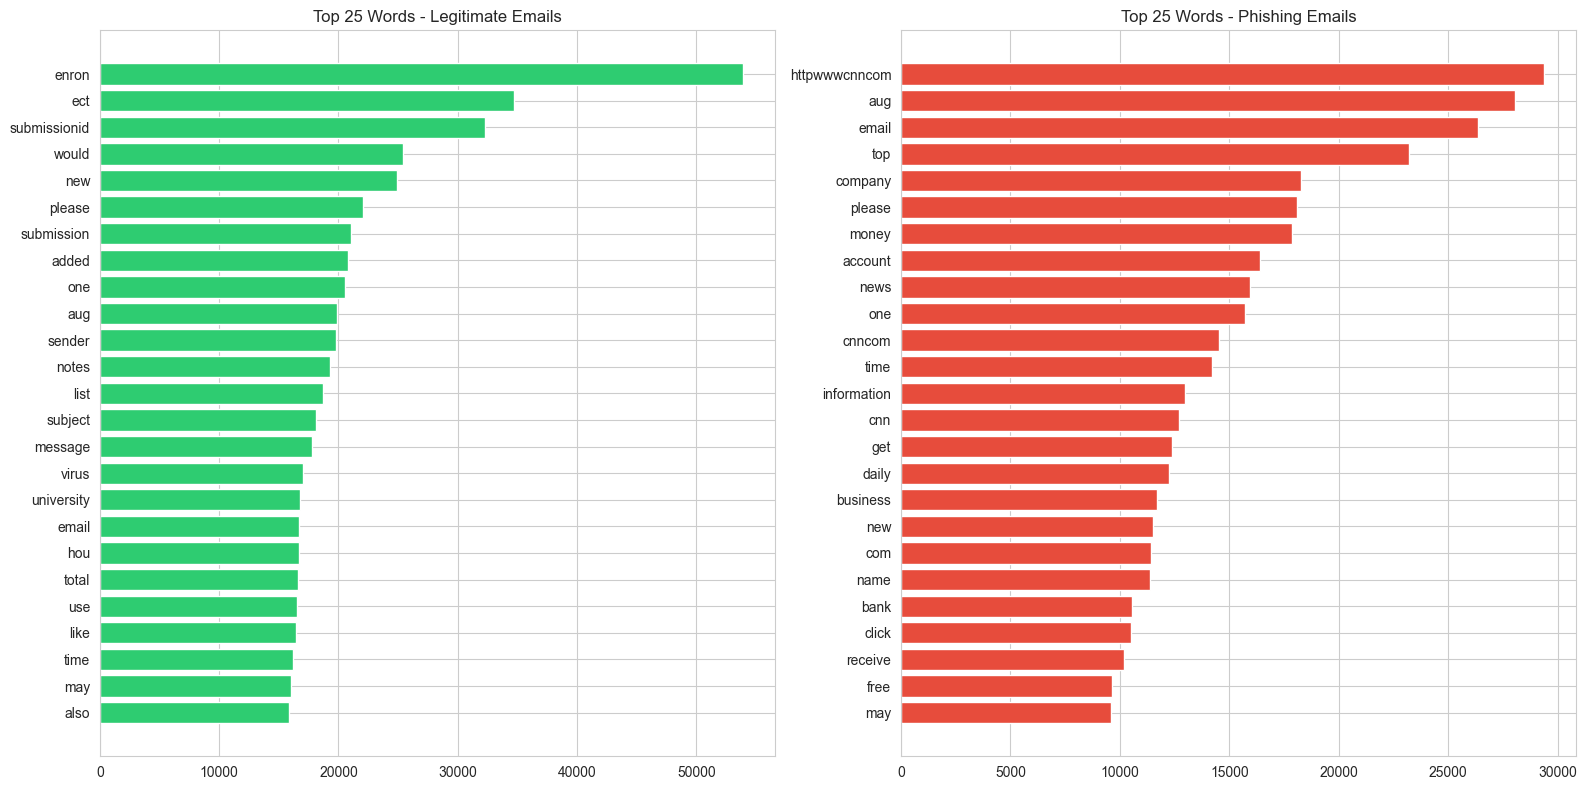

In [8]:
stop_words = set(stopwords.words('english'))

def get_top_words(texts, n=20):
    all_words = []
    for text in texts:
        if isinstance(text, str):
            words = re.findall(r'[a-zA-Z]{3,}', text.lower())
            words = [w for w in words if w not in stop_words]
            all_words.extend(words)
    return Counter(all_words).most_common(n)

phishing_words = get_top_words(df[df['label'] == 1]['text_combined'], 25)
legit_words = get_top_words(df[df['label'] == 0]['text_combined'], 25)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

words, counts = zip(*legit_words)
axes[0].barh(range(len(words)), counts, color='#2ecc71')
axes[0].set_yticks(range(len(words)))
axes[0].set_yticklabels(words)
axes[0].invert_yaxis()
axes[0].set_title('Top 25 Words - Legitimate Emails')

words, counts = zip(*phishing_words)
axes[1].barh(range(len(words)), counts, color='#e74c3c')
axes[1].set_yticks(range(len(words)))
axes[1].set_yticklabels(words)
axes[1].invert_yaxis()
axes[1].set_title('Top 25 Words - Phishing Emails')

plt.tight_layout()
plt.savefig('../results/top_words.png', dpi=150)
plt.show()

## 5. Phishing Indicator Analysis

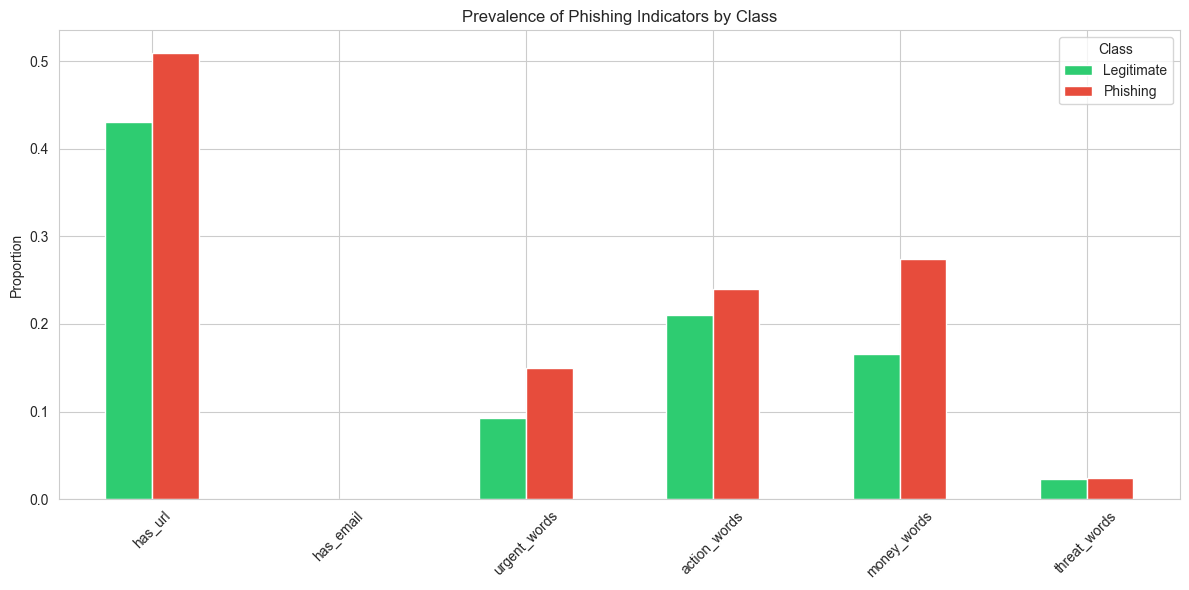


Indicator Proportions:
              Legitimate  Phishing
has_url         0.430231  0.509781
has_email       0.000000  0.000000
urgent_words    0.092486  0.149635
action_words    0.210708  0.239910
money_words     0.165779  0.274207
threat_words    0.023362  0.024667


In [9]:
# Check for phishing indicators
indicators = {
    'has_url': r'http|www\.',
    'has_email': r'\S+@\S+',
    'urgent_words': r'urgent|immediately|verify|suspend|expire|alert|warning',
    'action_words': r'click|confirm|update|login|sign in|reset|password',
    'money_words': r'money|dollar|bank|account|payment|credit|transfer|wire',
    'threat_words': r'suspend|terminate|deactivate|unauthorized|breach|compromise'
}

for name, pattern in indicators.items():
    df[name] = df['text_combined'].astype(str).str.contains(pattern, case=False, regex=True).astype(int)

indicator_cols = list(indicators.keys())
indicator_stats = df.groupby('label')[indicator_cols].mean()
indicator_stats.index = ['Legitimate', 'Phishing']

indicator_stats.T.plot(kind='bar', figsize=(12, 6), color=['#2ecc71', '#e74c3c'])
plt.title('Prevalence of Phishing Indicators by Class')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(title='Class')
plt.tight_layout()
plt.savefig('../results/phishing_indicators.png', dpi=150)
plt.show()

print("\nIndicator Proportions:")
print(indicator_stats.T.to_string())

## 6. Sample Emails

In [10]:
print("=" * 60)
print("SAMPLE LEGITIMATE EMAILS")
print("=" * 60)
for i, row in df[df['label'] == 0].sample(3, random_state=42).iterrows():
    print(f"\n--- Email {i} ---")
    print(row['text_combined'][:300])
    print("...")

print("\n" + "=" * 60)
print("SAMPLE PHISHING EMAILS")
print("=" * 60)
for i, row in df[df['label'] == 1].sample(3, random_state=42).iterrows():
    print(f"\n--- Email {i} ---")
    print(row['text_combined'][:300])
    print("...")

SAMPLE LEGITIMATE EMAILS

--- Email 39932 ---
ned deily riyacmorg article 51951867168434095nz5d8bhudamiredorg mike meyer wrote thu 28 feb 2008 234249 0000 utc medhat gayed wrote lxml good written python difficult install didnt work macos x lxml built top libxml2libxslt bundled unixlike oss including mac os x available package systems trying ins
...

--- Email 60118 ---
perl jobs xycnvtnhzperlorg online url job httpjobsperlorgjob7990 subscribe list send mail jobssubscribeperlorg unsubscribe send mail jobsunsubscribeperlorg posted february 21 2008 job title front end web developer company name ticketmaster location ca west hollywodd pay rate market travel 0 terms em
...

--- Email 16628 ---
model 04 28 good morning bill 4 28 could move 100 bookouts 5 6 6 00 top direct bill cuts psco deals keeping together also today end month probably checking amy kelley replacement houston wed thurs need models corrected thanks kathy
...

SAMPLE PHISHING EMAILS

--- Email 36711 ---
angel guerra dwthebal

## 7. Summary Statistics

In [11]:
print("Dataset Summary")
print("=" * 40)
print(f"Total emails: {len(df):,}")
print(f"Phishing emails: {(df['label']==1).sum():,} ({(df['label']==1).mean()*100:.1f}%)")
print(f"Legitimate emails: {(df['label']==0).sum():,} ({(df['label']==0).mean()*100:.1f}%)")
print(f"Avg word count (legitimate): {df[df['label']==0]['word_count'].mean():.0f}")
print(f"Avg word count (phishing): {df[df['label']==1]['word_count'].mean():.0f}")
print(f"\nDataset is {'balanced' if 0.8 < label_counts.min()/label_counts.max() else 'slightly imbalanced'}")
print(f"Class ratio: {label_counts.min()/label_counts.max():.3f}")

Dataset Summary
Total emails: 82,486
Phishing emails: 42,891 (52.0%)
Legitimate emails: 39,595 (48.0%)
Avg word count (legitimate): 203
Avg word count (phishing): 121

Dataset is balanced
Class ratio: 0.923
